In [1]:
import chardet
def detect_encoding(file_name):
    with open(file_name, 'rb') as file:
        raw_data = file.read()
    print(chardet.detect(raw_data))
    return chardet.detect(raw_data)['encoding']

In [2]:
print(detect_encoding('llmprice_data.csv'))

{'encoding': 'GB2312', 'confidence': 0.99, 'language': 'Chinese'}
GB2312


In [3]:
import pandas as pd

file_path = 'llmprice_data.csv'

data = pd.read_csv(file_path, encoding='GB2312')

data.head()


,模型名称,API提供商,输入价格 $\n1M Tokens,输出价格 $1M Tokens
0,GPT-4o,OpenAI,$5.00,$15.00
1,GPT-4 Turbo,OpenAI,$10.00,$30.00
2,GPT-4-32k,OpenAI,$60.00,$120.00
3,GPT-4,OpenAI,$30.00,$60.00
4,GPT-3.5-Turbo-0125,OpenAI,$0.50,$1.50


C:\Users\Administrator\AppData\Local\Temp\ipykernel_12672\1011827143.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data = data.applymap(lambda x: x.strip() if isinstance(x, str) else x)
C:\Users\Administrator\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26234 (\N{CJK UNIFIED IDEOGRAPH-667A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Roaming\Python\Python310\site-p

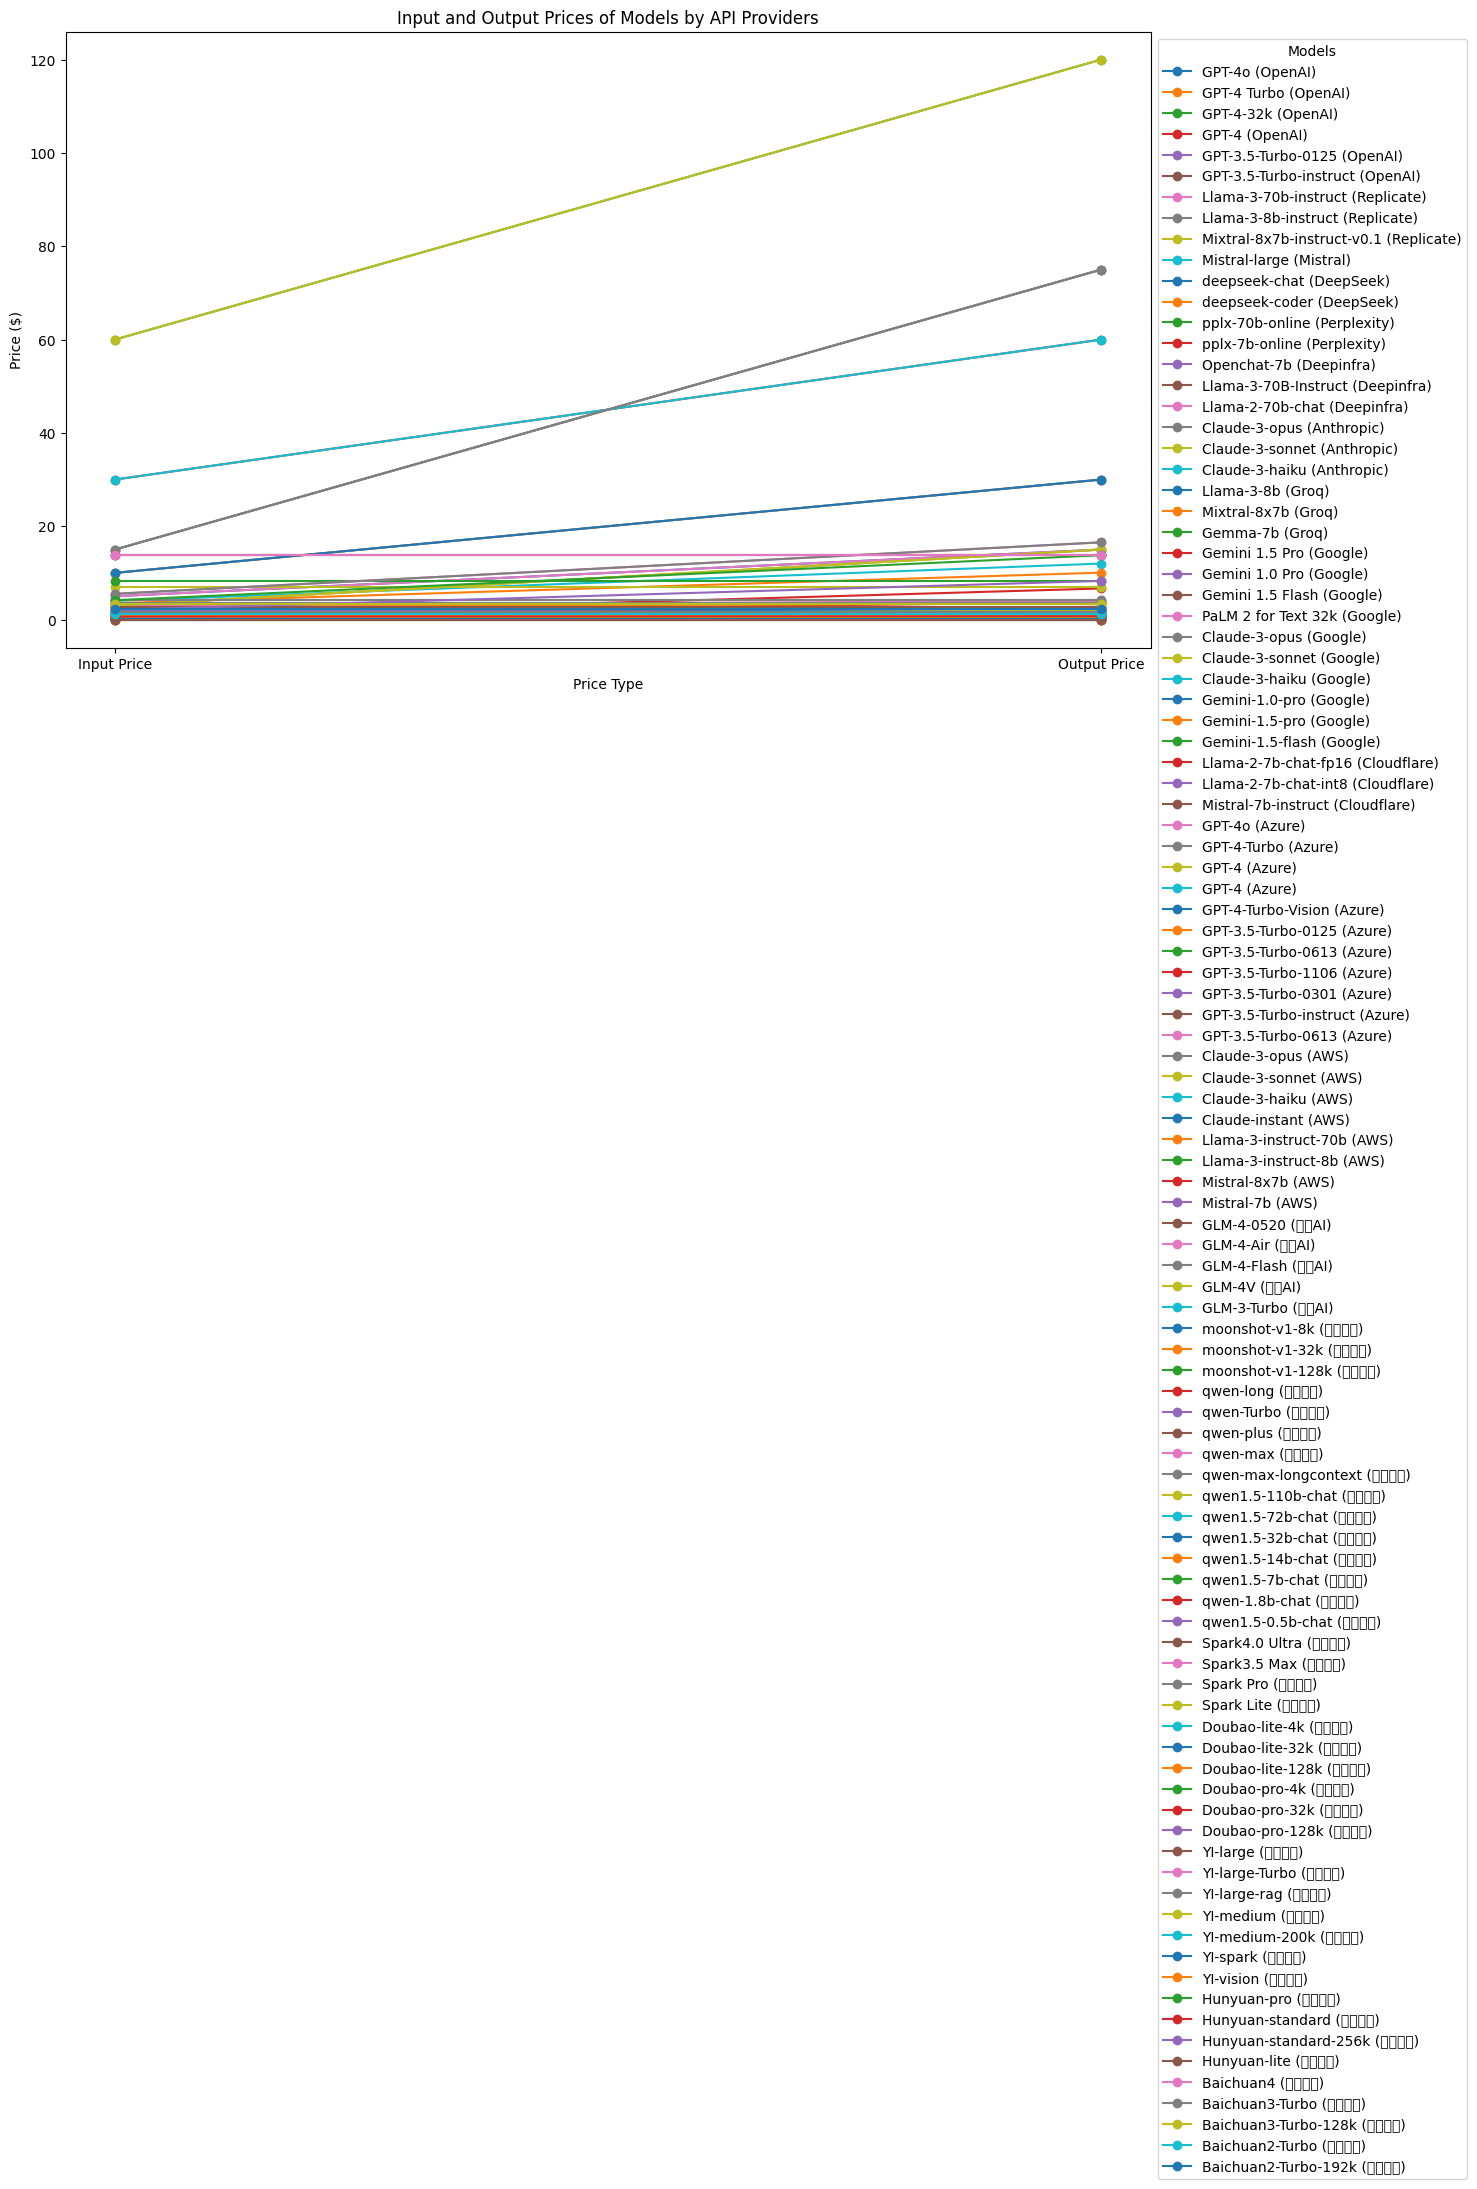

In [18]:
import matplotlib.pyplot as plt

# Renaming columns for clarity
data.columns = ["Model", "API_Provider", "Input_Price_$1M_Tokens", "Output_Price_$1M_Tokens"]

# Strip any leading/trailing whitespace from the data
data = data.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Convert price columns to numeric after removing the dollar sign and commas
data["Input_Price_$1M_Tokens"] = data["Input_Price_$1M_Tokens"].replace({'\$': '', ',': ''}, regex=True).astype(float)
data["Output_Price_$1M_Tokens"] = data["Output_Price_$1M_Tokens"].replace({'\$': '', ',': ''}, regex=True).astype(float)

# Plotting
plt.figure(figsize=(14, 8))

# Adjusting the x-axis positions to avoid overlap
x_positions = [0, 1]
x_offsets = [-0.2, -0.1, 0, 0.1, 0.2]  # Adjust these offsets as needed

for i, row in data.iterrows():
    plt.plot(['Input Price', 'Output Price'], 
             [row["Input_Price_$1M_Tokens"], row["Output_Price_$1M_Tokens"]], 
             marker='o', label=f"{row['Model']} ({row['API_Provider']})")

# Setting labels and title
plt.xlabel('Price Type')
plt.ylabel('Price ($)')
plt.title('Input and Output Prices of Models by API Providers')

# Adding a legend
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Models')

plt.show(True)